In [1]:
!pip install -q segmentation_models
%env SM_FRAMEWORK=tf.keras

env: SM_FRAMEWORK=tf.keras


In [2]:
import tensorflow as tf

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [3]:
import os
import math
import json
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
import tensorflow.keras.backend as K
import tensorflow.keras.layers as tfl
import segmentation_models as sm

Segmentation Models: using `tf.keras` framework.


In [4]:
import warnings
warnings.filterwarnings("ignore")

# Conf

In [5]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

In [6]:
CONF = {
    'a_min': -110, 
    'a_max': 200,
    'batch_size': 10,
    'lr': 1e-4,
    'epochs': 250,
    'img_size': [256, 256],
    'channels': 5,
    
    'fill_mode': 'constant',
    'rot': 8.0,  
    'shr': 8.0,  
    'hzoom': 125.0, 
    'wzoom': 125.0,  
    'hshift': 8.0,  
    'wshift': 8.0, 

    'hflip': 0.5,
    'vflip': 0.5,

    'drop_prob': 0.5,
    'drop_cnt': 10,
    'drop_size': 0.05,

    'sat': [0.7, 1.3],  
    'cont': [0.8, 1.2], 
    'bri': 0.15,
    'hue': 0.0,  
    
    'architecture': 'Unet 5s',
    'loss': 'DiceLoss',
    'metric': 'FScore',
    'lr_scheduler': 'CosineDecay',
    'augment': True
}

DIR_PATH = '/kaggle/input/couinaud-segmentation-processed-256x256x5'
TRAIN_SET = tf.io.gfile.glob(f'{DIR_PATH}/train_set/*.tfrecords')
DEV_SET = tf.io.gfile.glob(f'{DIR_PATH}/dev_set/*.tfrecords')
TEST_SET = tf.io.gfile.glob(f'{DIR_PATH}/test_set/*.tfrecords')

with tf.io.gfile.GFile(f'{DIR_PATH}/size.json', 'r') as f:
    SET_SIZE = json.load(f)
AUTO = tf.data.experimental.AUTOTUNE

In [7]:
print(f"Number of training records: {len(TRAIN_SET)}")
print(f"Number of validation records: {len(DEV_SET)}")
print(f"Number of test records: {len(TEST_SET)}")

Number of training records: 160
Number of validation records: 19
Number of test records: 14


In [8]:
DIR_PATH

'/kaggle/input/couinaud-segmentation-processed-256x256x5'

## Utils

In [9]:
def random_int(shape=[], minval=0, maxval=1):
    return tf.random.uniform(shape=shape, minval=minval, maxval=maxval, dtype=tf.int32)

def random_float(shape=[], minval=0.0, maxval=1.0):
    rnd = tf.random.uniform(shape=shape, minval=minval, maxval=maxval, dtype=tf.float32)
    return rnd

def get_mat(shear, height_zoom, width_zoom, height_shift, width_shift):
    shear = math.pi * shear / 180.0
    def get_3x3_mat(lst):
        return tf.reshape(tf.concat([lst], axis=0), [3, 3])
    one = tf.constant([1], dtype='float32')
    zero = tf.constant([0], dtype='float32')

    c2 = tf.math.cos(shear)
    s2 = tf.math.sin(shear)
    shear_matrix = get_3x3_mat([one, s2, zero, zero, c2, zero, zero, zero, one])
    
    zoom_matrix = get_3x3_mat(
        [one / height_zoom, zero, zero, zero, one / width_zoom, zero, zero, zero, one]
    )
    
    shift_matrix = get_3x3_mat(
        [one, zero, height_shift, zero, one, width_shift, zero, zero, one]
    )
    return K.dot(
        shear_matrix, K.dot(zoom_matrix, shift_matrix)
    )  

## Augmentation functions

In [10]:
def ShiftScaleRotate(image, mask=None, DIM=CONF['img_size'], p=1.0):
    if random_float() > p:
        return image, mask

    # --- Padding ---
    orig_height, orig_width = DIM[0], DIM[1]
    padded_image = image
    padded_mask = mask # Initialize padded_mask to the original mask
    NEW_DIM = max(orig_height, orig_width)

    pad_top = (NEW_DIM - orig_height) // 2
    pad_bottom = NEW_DIM - orig_height - pad_top
    pad_left = (NEW_DIM - orig_width) // 2
    pad_right = NEW_DIM - orig_width - pad_left

    if orig_height != orig_width:
        # Define paddings for image
        paddings_img = [[pad_top, pad_bottom], [pad_left, pad_right], [0, 0]]
        padded_image = tf.pad(image, paddings_img, mode='CONSTANT', constant_values=0.0)

        if mask is not None:
             # Define paddings for mask (only needed if padding happens)
             paddings_mask = [[pad_top, pad_bottom], [pad_left, pad_right], [0, 0]]
             # Perform dtype check and conditional padding HERE
             if mask.dtype == tf.float32: # Check original mask dtype
                  padded_mask = tf.pad(mask, paddings_mask, mode='CONSTANT', constant_values=0.0)
             else:
                  padded_mask = tf.pad(mask, paddings_mask, mode='CONSTANT', constant_values=0)
    # ELSE (if image is square): padded_image remains 'image', padded_mask remains 'mask'

    # Reshape must happen *after* potential padding
    padded_image = tf.reshape(padded_image, [NEW_DIM, NEW_DIM, CONF["channels"]])
    if mask is not None:
         # Reshape whatever padded_mask ended up being (original or padded)
         padded_mask = tf.reshape(padded_mask, [NEW_DIM, NEW_DIM, 9])


    # --- Get random transform parameters ---
    rot = CONF['rot'] * tf.random.normal([1], dtype="float32")
    shr = CONF['shr'] * tf.random.normal([1], dtype="float32")
    h_zoom = 1.0 + tf.random.normal([1], dtype="float32") / (CONF['hzoom'] * 2)
    w_zoom = 1.0 + tf.random.normal([1], dtype="float32") / (CONF['wzoom'] * 2)
    h_shift = CONF['hshift'] * tf.random.normal([1], dtype="float32")
    w_shift = CONF['wshift'] * tf.random.normal([1], dtype="float32")

    # --- Combined Affine + Rotation Matrix ---
    center_x = tf.cast(NEW_DIM, tf.float32) / 2.0
    center_y = tf.cast(NEW_DIM, tf.float32) / 2.0

    rotation_radians = math.pi * rot / 180.0

    affine_matrix = get_mat(shr, h_zoom, w_zoom, h_shift, w_shift)

    c1 = tf.math.cos(rotation_radians[0])
    s1 = tf.math.sin(rotation_radians[0])
    zero_tensor = tf.constant(0.0, dtype=tf.float32)
    one_tensor = tf.constant(1.0, dtype=tf.float32)

    rotation_matrix_flat = tf.stack([
        c1, s1, zero_tensor,
       -s1, c1, zero_tensor,
        zero_tensor, zero_tensor, one_tensor
    ])
    rotation_matrix_3x3 = tf.reshape(rotation_matrix_flat, [3, 3])

    row1_c = tf.stack([one_tensor, zero_tensor, -center_x])
    row2_c = tf.stack([zero_tensor, one_tensor, -center_y])
    row3_c = tf.stack([zero_tensor, zero_tensor, one_tensor])
    center_mat = tf.stack([row1_c, row2_c, row3_c])

    row1_u = tf.stack([one_tensor, zero_tensor, center_x])
    row2_u = tf.stack([zero_tensor, one_tensor, center_y])
    row3_u = tf.stack([zero_tensor, zero_tensor, one_tensor])
    uncenter_mat = tf.stack([row1_u, row2_u, row3_u])

    full_transform_matrix = uncenter_mat @ affine_matrix @ rotation_matrix_3x3 @ center_mat

    inv_transform_matrix = tf.linalg.inv(full_transform_matrix)
    flat_inv_transform = tf.reshape(inv_transform_matrix, [-1])[0:8]

    # --- Apply Transform using tf.raw_ops ---
    output_shape = tf.constant([NEW_DIM, NEW_DIM], dtype=tf.int32)

    transformed_image = tf.raw_ops.ImageProjectiveTransformV3(
        images=padded_image[None,...],
        transforms=flat_inv_transform[None,...],
        output_shape=output_shape,
        fill_mode=CONF['fill_mode'].upper(),
        fill_value=0.0,
        interpolation='BILINEAR'
    )[0]

    transformed_mask = None
    if mask is not None: # Use original 'mask' here to check if we need to transform
        # Determine fill value based on the DTYPE of the mask *before* potential padding
        mask_fill_value = 0.0 if mask.dtype == tf.float32 else 0
        transformed_mask = tf.raw_ops.ImageProjectiveTransformV3(
             images=padded_mask[None,...], # Transform the potentially padded mask
             transforms=flat_inv_transform[None,...],
             output_shape=output_shape,
             fill_mode=CONF['fill_mode'].upper(),
             # Use the correct dtype for fill_value based on the original mask
             fill_value=tf.cast(mask_fill_value, mask.dtype),
             interpolation='NEAREST'
        )[0]

    # --- Unpad ---
    if orig_height != orig_width:
        transformed_image = tf.slice(transformed_image, [pad_top, pad_left, 0], [orig_height, orig_width, CONF["channels"]])
        if transformed_mask is not None:
             transformed_mask = tf.slice(transformed_mask, [pad_top, pad_left, 0], [orig_height, orig_width, 9])

    # Ensure final shapes
    transformed_image = tf.reshape(transformed_image, [*DIM, CONF["channels"]])
    if transformed_mask is not None:
        transformed_mask = tf.reshape(transformed_mask, [*DIM, 9])

    return transformed_image, transformed_mask

In [11]:
def CutOut(image, mask=None, DIM=CONF['img_size'], PROBABILITY=0.6, CT=5, SZ=0.1):
    P = tf.cast(random_float() < PROBABILITY, tf.int32)
    if (P == 0) | (CT == 0) | (SZ == 0):
        return image, mask

    for k in range(CT):
        x = tf.cast(tf.random.uniform([], 0, DIM[1]), tf.int32)
        y = tf.cast(tf.random.uniform([], 0, DIM[0]), tf.int32)

        WIDTH = tf.cast(SZ * min(DIM), tf.int32) * P
        ya = tf.math.maximum(0, y - WIDTH // 2)
        yb = tf.math.minimum(DIM[0], y + WIDTH // 2)
        xa = tf.math.maximum(0, x - WIDTH // 2)
        xb = tf.math.minimum(DIM[1], x + WIDTH // 2)

        one = image[ya:yb, 0:xa, :]
        two = tf.zeros([yb - ya, xb - xa, CONF["channels"]], dtype=image.dtype)
        three = image[ya:yb, xb : DIM[1], :]
        middle = tf.concat([one, two, three], axis=1)
        image = tf.concat([image[0:ya, :, :], middle, image[yb : DIM[0], :, :]], axis=0)
        image = tf.reshape(image, [*DIM, CONF["channels"]])

        if mask is not None:
            one = mask[ya:yb, 0:xa, :]
            two = tf.zeros([yb - ya, xb - xa, 9], dtype=mask.dtype)
            three = mask[ya:yb, xb : DIM[1], :]
            middle = tf.concat([one, two, three], axis=1)
            mask = tf.concat(
                [mask[0:ya, :, :], middle, mask[yb : DIM[0], :, :]], axis=0
            )
            mask = tf.reshape(mask, [*DIM, 9])
    return image, mask
    
def RandomFlip(img, msk=None, hflip_p=0.5, vflip_p=0.5):
    if random_float() < hflip_p:
        img = tf.image.flip_left_right(img)
        if msk is not None:
            msk = tf.image.flip_left_right(msk)
    if random_float() < vflip_p:
        img = tf.image.flip_up_down(img)
        if msk is not None:
            msk = tf.image.flip_up_down(msk)
    return img, msk

# Data Pipeline

In [12]:
def decode_image(data):
    image = tf.io.decode_raw(data, out_type=tf.int16)
    image = tf.reshape(image, (*CONF['img_size'], CONF['channels']))
    image = (tf.cast(image, tf.float32) - CONF['a_min']) / (CONF['a_max'] - CONF['a_min'])
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image

def decode_mask(data):    
    mask = tf.io.decode_raw(data, out_type=tf.int8)
    mask = tf.reshape(mask, CONF['img_size'])
    mask = tf.one_hot(mask, depth=9)
    return mask

def read_labeled_tfrecord(example, augment=True):
    LABELED_TFREC_FORMAT = {
        'image_raw': tf.io.FixedLenFeature([], tf.string),
        'mask_raw': tf.io.FixedLenFeature([], tf.string)
    }
    example = tf.io.parse_single_example(example, LABELED_TFREC_FORMAT)
    img = decode_image(example['image_raw'])
    msk = decode_mask(example['mask_raw'])
    if augment:  
        img, msk = ShiftScaleRotate(img, msk, DIM=CONF['img_size'], p=0.75)
        img, msk = RandomFlip(img, msk, hflip_p=CONF['hflip'], vflip_p=CONF['vflip'])
        img, msk = CutOut(
            img,
            msk,
            DIM=CONF['img_size'],
            PROBABILITY=CONF['drop_prob'],
            CT=CONF['drop_cnt'],
            SZ=CONF['drop_size'],
        )
    return img, msk 

def get_dataset(paths, training=True, augment=True):
    dataset = tf.data.TFRecordDataset(paths, num_parallel_reads=AUTO) 
    ignore_order = tf.data.Options()
    ignore_order.experimental_deterministic = False
    dataset = dataset.with_options(ignore_order)
    dataset = dataset.cache()
    if training:
        dataset = dataset.repeat() 
        dataset = dataset.shuffle(1024)
    dataset = dataset.map(
        lambda x: read_labeled_tfrecord(x, augment=augment), 
        num_parallel_calls=AUTO
    )
    dataset = dataset.batch(CONF['batch_size'], drop_remainder=True)
    dataset = dataset.prefetch(AUTO) 
    return dataset

# LR Scheduler

In [13]:
cosine_decay_scheduler = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=CONF['lr'],
    decay_steps=(CONF['epochs']+4) * SET_SIZE['train_set'] // CONF['batch_size'],
    alpha=1e-2
)
optimizer = tf.keras.optimizers.Adam(learning_rate=cosine_decay_scheduler)

# Unet

In [14]:
def se_block(input_tensor, reduction=16):
    filters = input_tensor.shape[-1]
    se = tfl.GlobalAveragePooling2D()(input_tensor)
    se = tfl.Dense(filters // reduction, activation='relu')(se)
    se = tfl.Dense(filters, activation='sigmoid')(se)
    return tfl.Multiply()([input_tensor, se])


def attention_block(x, g, inter_channel):
    theta_x = tfl.Conv2D(inter_channel, (1, 1), strides=(1, 1), padding='same')(x)
    phi_g = tfl.Conv2D(inter_channel, (1, 1), strides=(1, 1), padding='same')(g)
    add = tfl.Add()([theta_x, phi_g])
    act = tfl.Activation('relu')(add)
    psi = tfl.Conv2D(1, (1, 1), strides=(1, 1), padding='same')(act)
    psi = tfl.Activation('sigmoid')(psi)
    return tfl.Multiply()([x, psi])


def conv_3x3_bn_relu_dilated(filters, dilation_rate=2):
    def wrapper(input_tensor):
        x = tfl.Conv2D(filters, 3, padding='same', use_bias=False, dilation_rate=dilation_rate)(input_tensor)
        x = tfl.BatchNormalization()(x)
        x = tfl.Activation('relu')(x)
        return x
    return wrapper

In [15]:
def base_model(input_shape):
    base_model_3ch = tf.keras.applications.efficientnet.EfficientNetB3(
        include_top=False,
        weights='imagenet',
        input_shape=(input_shape[0], input_shape[1], 3)
    )

    first_conv_layer = base_model_3ch.get_layer('stem_conv_pad')
    if not isinstance(first_conv_layer, tfl.Conv2D):
         first_conv_layer = base_model_3ch.get_layer('stem_conv')

    # --- FIX STARTS HERE ---
    weights_list = first_conv_layer.get_weights()
    old_weights = weights_list[0]
    old_biases = None
    if len(weights_list) == 2:
        old_biases = weights_list[1]
    # --- FIX ENDS HERE ---

    new_weights_shape = (
        old_weights.shape[0],
        old_weights.shape[1],
        input_shape[2],
        old_weights.shape[3]
    )

    new_weights = np.zeros(new_weights_shape, dtype=np.float32)

    new_weights[:, :, 0:3, :] = old_weights[:, :, 0:3, :]

    avg_weights = np.mean(old_weights, axis=2, keepdims=True)
    new_weights[:, :, 3:5, :] = avg_weights

    base_model_5ch = tf.keras.applications.efficientnet.EfficientNetB3(
        include_top=False,
        weights=None,
        input_shape=input_shape
    )

    first_conv_layer_5ch = base_model_5ch.get_layer(first_conv_layer.name)

    # --- ADJUST WEIGHT SETTING ---
    if old_biases is not None:
        first_conv_layer_5ch.set_weights([new_weights, old_biases])
    else:
        first_conv_layer_5ch.set_weights([new_weights]) # Only set kernel weights
    # --- END ADJUSTMENT ---

    for layer_3ch, layer_5ch in zip(base_model_3ch.layers, base_model_5ch.layers):
        if layer_3ch.name == first_conv_layer.name:
            continue
        if layer_3ch.get_weights():
            try:
                 layer_5ch.set_weights(layer_3ch.get_weights())
            except ValueError as e:
                 print(f"Skipping weights for layer {layer_5ch.name} due to shape mismatch: {e}")


    for layer in base_model_5ch.layers:
        layer.trainable = True

    layer_names = [
        'block2a_expand_activation',
        'block3a_expand_activation',
        'block4a_expand_activation',
        'block6a_expand_activation',
    ]
    base_outputs = [base_model_5ch.get_layer(name).output for name in layer_names]

    down_stack = tf.keras.Model(inputs=base_model_5ch.input, outputs=base_outputs)
    down_stack_filters = [base_model_5ch.get_layer(name).output_shape[-1] for name in layer_names]

    return down_stack, down_stack_filters

def conv_3x3_bn_relu(filters):
    def wrapper(input_tensor):
        x = tfl.Conv2D(filters, 3, padding='same', use_bias=False)(input_tensor) 
        x = tfl.BatchNormalization()(x)
        x = tfl.Activation('relu')(x)
        return x
    return wrapper

def upsample(filters):
    def wrapper(input_tensor):
        x = tfl.Conv2DTranspose(filters, 
                                kernel_size=4, 
                                strides=2,
                                padding='same', 
                                use_bias=False)(input_tensor)
        x = tfl.BatchNormalization()(x)
        x = tfl.Activation('relu')(x)
        return x
    return wrapper

In [16]:
def unet_model(input_shape, classes):
    inputs = tfl.Input(shape=input_shape)

    down_stack, down_stack_filters = base_model(input_shape)
    skips = down_stack(inputs)

    x = skips[-1]
    for _ in range(3):
        x = conv_3x3_bn_relu(x.shape[-1])(x)

    skips = reversed(skips[:-1])
    base_filters = reversed(down_stack_filters[:-1])

    for skip, filters in zip(skips, base_filters):
        x = upsample(filters)(x)
        x = tfl.Concatenate()([x, skip])
        x = conv_3x3_bn_relu(filters)(x)
        x = conv_3x3_bn_relu(filters)(x)

    x = upsample(classes)(x)
    skip = inputs # <-- USE ORIGINAL INPUTS (now normalized 0 to 1)
    x = tfl.Concatenate()([x, skip])
    x = conv_3x3_bn_relu(128)(x)
    x = conv_3x3_bn_relu(64)(x)
    x = tfl.Conv2D(classes, 3, padding='same')(x)
    outputs = tfl.Activation('softmax')(x)

    return tf.keras.Model(inputs=inputs, outputs=outputs)

# Train

In [17]:
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler, ReduceLROnPlateau, ModelCheckpoint

In [18]:
import tensorflow.keras.backend as K
import tensorflow as tf

def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    
    intersection = K.sum(y_true_f * y_pred_f)
    
    dice = (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)
    
    return 1. - dice

def f1_score(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    
    intersection = K.sum(y_true_f * y_pred_f)
    
    dice = (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)
    
    return dice

In [19]:
model = unet_model(input_shape=(*CONF['img_size'], CONF['channels']), classes=9)
cce = tf.keras.losses.CategoricalCrossentropy()

def combined_loss(y_true, y_pred):
    return cce(y_true, y_pred) + dice_loss(y_true, y_pred)

model.compile(
    optimizer=optimizer, 
    loss=combined_loss,   
    metrics=[f1_score]    
)

model.summary()

43941136/43941136 [==============================] - 0s 0us/step
Skipping weights for layer normalization_1 due to shape mismatch: Layer normalization_1 weight shape (5,) is not compatible with provided weight shape (3,).
Skipping weights for layer stem_activation due to shape mismatch: You called `set_weights(weights)` on layer "stem_activation" with a weight list of length 4, but the layer was expecting 0 weights. Provided weights: [array([ 0.1913209 ,  2.7074034 ,  9.623442  ,  2....
Skipping weights for layer block1a_bn due to shape mismatch: You called `set_weights(weights)` on layer "block1a_bn" with a weight list of length 1, but the layer was expecting 4 weights. Provided weights: [array([[[[ 9.77612659e-03],
         [-2.16964185...
Skipping weights for layer block1a_activation due to shape mismatch: You called `set_weights(weights)` on layer "block1a_activation" with a weight list of length 4, but the layer was expecting 0 weights. Provided weights: [array([2.0295367 , 1.2236

In [20]:
checkpoint = ModelCheckpoint(
    'best_weights.keras',  
    monitor='val_f1_score', 
    save_best_only=True,  
    mode='max',           
    verbose=1           
)

early_stopping = EarlyStopping(
    monitor='val_f1_score', 
    patience=5, 
    min_delta=0.002, 
    mode='max'  
)

callbacks_list = [
    checkpoint,
    early_stopping 
]

In [21]:
train_ds = get_dataset(TRAIN_SET, augment=CONF['augment'])
valid_ds = get_dataset(DEV_SET, training=False, augment=False)
test_ds = get_dataset(TEST_SET, training=False, augment=False)

hist = model.fit(
    train_ds,
    steps_per_epoch=SET_SIZE['train_set'] // CONF['batch_size'],
    epochs=50,
    callbacks=callbacks_list,
    validation_data=valid_ds
)

Epoch 1/50


2025-10-25 13:03:11.289481: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel_1/model/block1b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


533/533 [==============================] - ETA: 0s - loss: 1.0229 - f1_score: 0.6547
Epoch 1: val_f1_score improved from -inf to 0.34574, saving model to best_weights.keras
533/533 [==============================] - 279s 423ms/step - loss: 1.0229 - f1_score: 0.6547 - val_loss: 2.4602 - val_f1_score: 0.3457
Epoch 2/50
533/533 [==============================] - ETA: 0s - loss: 0.7473 - f1_score: 0.7306
Epoch 2: val_f1_score improved from 0.34574 to 0.79667, saving model to best_weights.keras
533/533 [==============================] - 223s 418ms/step - loss: 0.7473 - f1_score: 0.7306 - val_loss: 0.5985 - val_f1_score: 0.7967
Epoch 3/50
533/533 [==============================] - ETA: 0s - loss: 0.6870 - f1_score: 0.7494
Epoch 3: val_f1_score did not improve from 0.79667
533/533 [==============================] - 223s 418ms/step - loss: 0.6870 - f1_score: 0.7494 - val_loss: 0.5897 - val_f1_score: 0.7942
Epoch 4/50
533/533 [==============================] - ETA: 0s - loss: 0.6495 - f1_score:

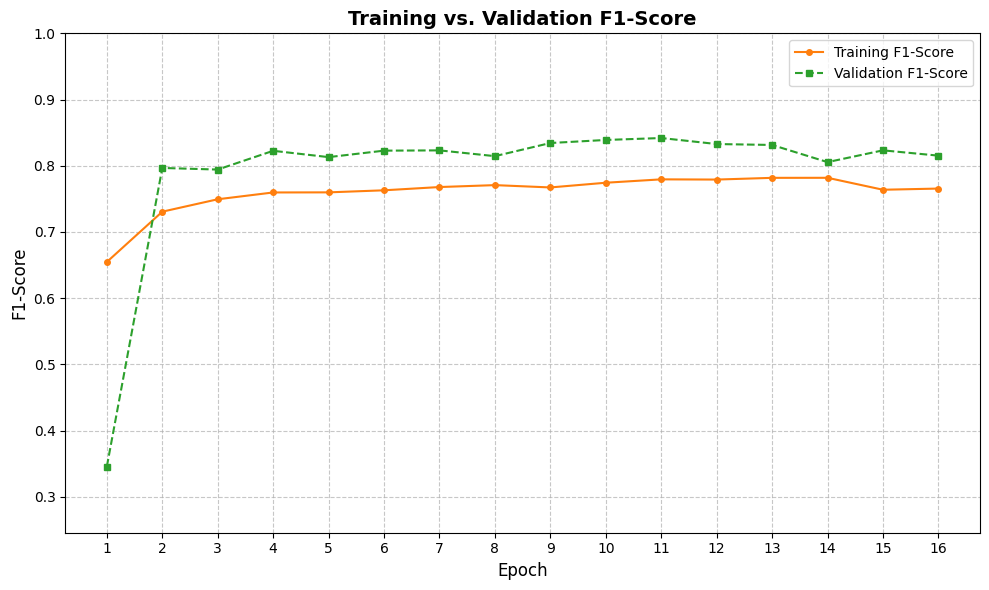

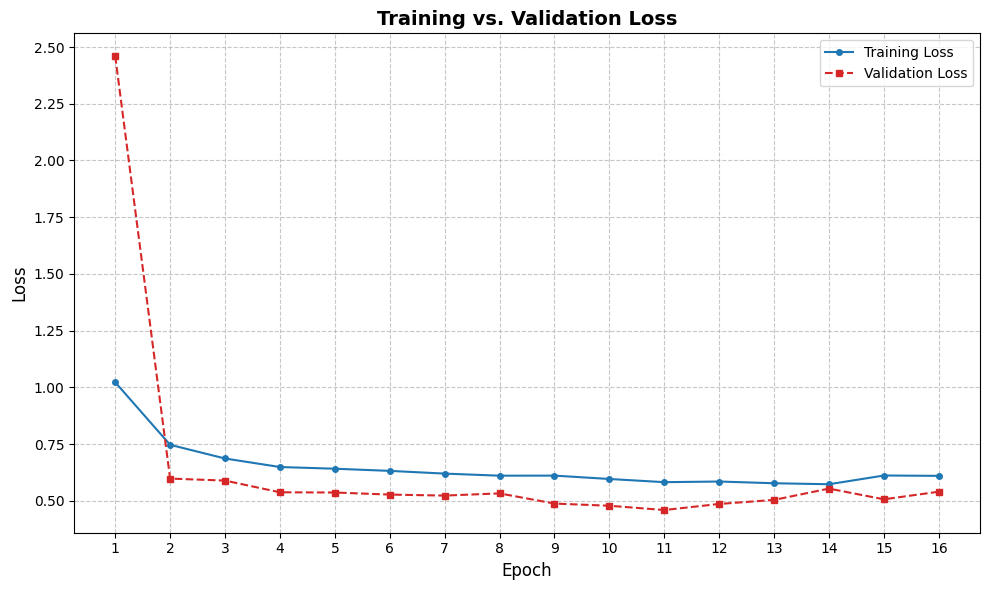

In [22]:
import matplotlib.pyplot as plt
import numpy as np

try:
    epochs = np.array(hist.epoch) + 1
    num_epochs = len(epochs)

    plt.figure(figsize=(10, 6))

    # Plot F1 Scores
    plt.plot(epochs, hist.history['f1_score'], label='Training F1-Score', color='tab:orange', linestyle='-', marker='o', markersize=4)
    plt.plot(epochs, hist.history['val_f1_score'], label='Validation F1-Score', color='tab:green', linestyle='--', marker='s', markersize=4)

    plt.title('Training vs. Validation F1-Score', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('F1-Score', fontsize=12)

    if num_epochs <= 20:
         plt.xticks(epochs)
    else:
         plt.xticks(np.arange(1, num_epochs + 1, step=max(1, num_epochs // 10)))

    plt.legend(fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.ylim(bottom=max(0, min(hist.history['f1_score'] + hist.history['val_f1_score']) - 0.1), top=1.0) # Adjust y-axis range
    plt.tight_layout()
    plt.show()

    # --- Optional: Combined Loss Plot ---
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, hist.history['loss'], label='Training Loss', color='tab:blue', linestyle='-', marker='o', markersize=4)
    plt.plot(epochs, hist.history['val_loss'], label='Validation Loss', color='tab:red', linestyle='--', marker='s', markersize=4)
    plt.title('Training vs. Validation Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    if num_epochs <= 20: plt.xticks(epochs)
    else: plt.xticks(np.arange(1, num_epochs + 1, step=max(1, num_epochs // 10)))
    plt.legend(fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


except KeyError as e:
    print(f"Error plotting combined metrics: Metric key '{e}' not found.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Evaluating on test set for per-class metrics...
Evaluation finished.


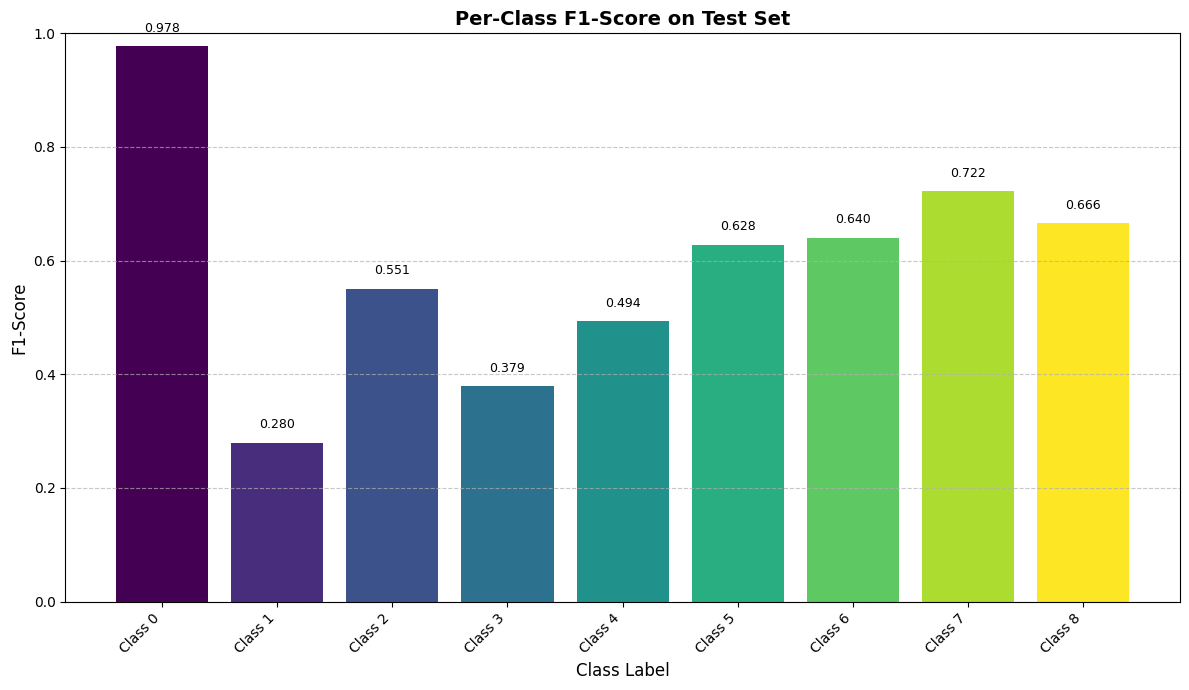

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score as sk_f1_score # Use scikit-learn for easier per-class calculation

# --- IMPORTANT: Run this AFTER training and loading best weights ---
# --- You need predictions and ground truth for the test set ---

all_true_masks = []
all_pred_masks = []

print("Evaluating on test set for per-class metrics...")
# Ensure test_ds is not repeating for evaluation
test_ds_eval = get_dataset(TEST_SET, training=False, augment=False)

for images, masks in test_ds_eval:
    preds = model.predict(images, verbose=0)
    # Convert predictions and masks to class indices (argmax)
    true_labels = tf.argmax(masks, axis=-1).numpy().flatten()
    pred_labels = tf.argmax(preds, axis=-1).numpy().flatten()
    all_true_masks.extend(true_labels)
    all_pred_masks.extend(pred_labels)

print("Evaluation finished.")

try:
    # Calculate per-class F1 using scikit-learn
    # labels=range(9) ensures all classes are included, even if not present in batch
    # average=None returns score for each class
    per_class_f1 = sk_f1_score(all_true_masks, all_pred_masks, average=None, labels=range(9), zero_division=0)

    class_labels = [f'Class {i}' for i in range(9)] # Replace with actual names if available

    plt.figure(figsize=(12, 7))
    bars = plt.bar(class_labels, per_class_f1, color=plt.cm.viridis(np.linspace(0, 1, 9))) # Use a colormap

    plt.title('Per-Class F1-Score on Test Set', fontsize=14, fontweight='bold')
    plt.xlabel('Class Label', fontsize=12)
    plt.ylabel('F1-Score', fontsize=12)
    plt.xticks(rotation=45, ha='right') # Rotate labels if needed
    plt.ylim(0, 1)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Add score labels on top of bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f'{yval:.3f}', va='bottom', ha='center', fontsize=9)


    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"An unexpected error occurred plotting per-class F1: {e}")

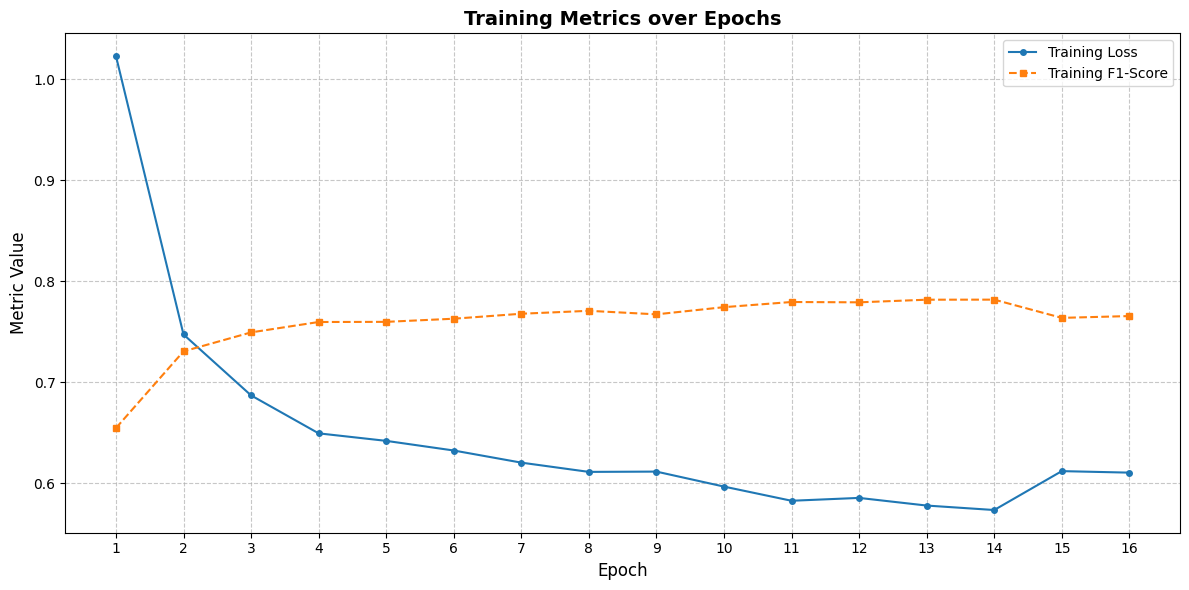

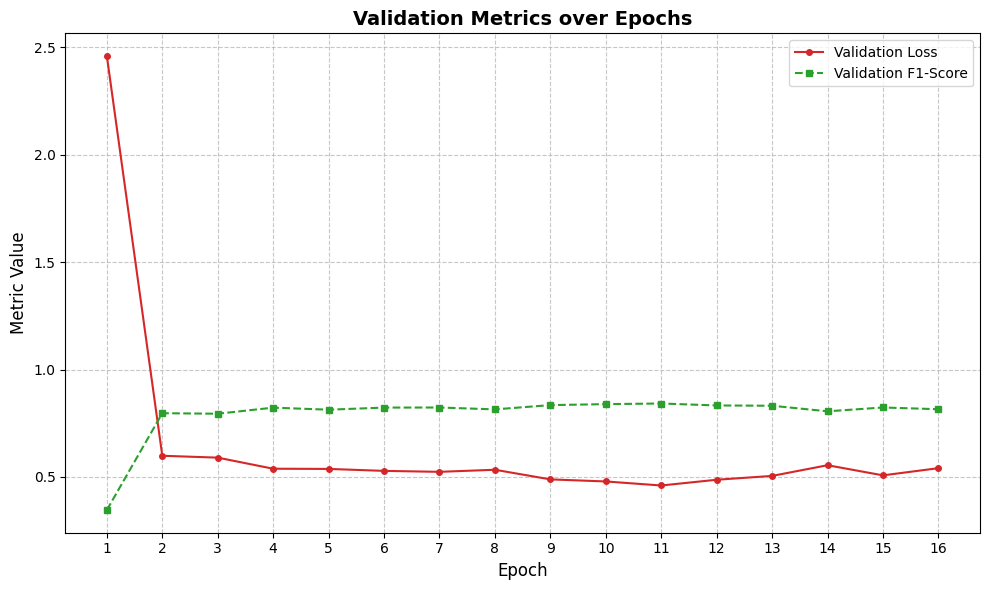

In [24]:
try:
    epochs = np.array(hist.epoch) + 1
    num_epochs = len(epochs)

    plt.figure(figsize=(12, 6))

    plt.plot(epochs, hist.history['loss'], label='Training Loss', color='tab:blue', linestyle='-', marker='o', markersize=4)

    plt.plot(epochs, hist.history['f1_score'], label='Training F1-Score', color='tab:orange', linestyle='--', marker='s', markersize=4)

    plt.title('Training Metrics over Epochs', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Metric Value', fontsize=12)

    if num_epochs <= 20:
         plt.xticks(epochs)
    else:
         plt.xticks(np.arange(1, num_epochs + 1, step=max(1, num_epochs // 10)))


    plt.legend(fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout() 
    plt.show()

except KeyError as e:
    print(f"Error plotting training metrics: Metric key '{e}' not found in history.")
except Exception as e:
    print(f"An unexpected error occurred while plotting training metrics: {e}")


try:
    epochs = np.array(hist.epoch) + 1
    num_epochs = len(epochs)

    plt.figure(figsize=(10, 6)) 

    plt.plot(epochs, hist.history['val_loss'], label='Validation Loss', color='tab:red', linestyle='-', marker='o', markersize=4)

    plt.plot(epochs, hist.history['val_f1_score'], label='Validation F1-Score', color='tab:green', linestyle='--', marker='s', markersize=4)

    plt.title('Validation Metrics over Epochs', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Metric Value', fontsize=12)

    if num_epochs <= 20:
         plt.xticks(epochs)
    else:
         plt.xticks(np.arange(1, num_epochs + 1, step=max(1, num_epochs // 10)))


    plt.legend(fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

except KeyError as e:
    print(f"Error plotting validation metrics: Metric key '{e}' not found in history.")
    print("Available keys:", hist.history.keys()) # Help debug if keys are named differently
except Exception as e:
    print(f"An unexpected error occurred while plotting validation metrics: {e}")

# Visualize output

In [25]:
def display(display_list):
    plt.figure(figsize=(15, 15))
    title = ['Input Image', 'True Mask', 'Predicted Mask']
    for i in range(len(display_list)):
        plt.subplot(1, len(display_list), i+1)
        plt.title(title[i])
        plt.imshow(display_list[i])
        plt.axis('off')
    plt.show()

In [26]:
try:
    model.load_weights('best_weights.keras')
except Exception as e:
    print(f"Error loading best weights: {e}")

1/1 [==============================] - 0s 455ms/step


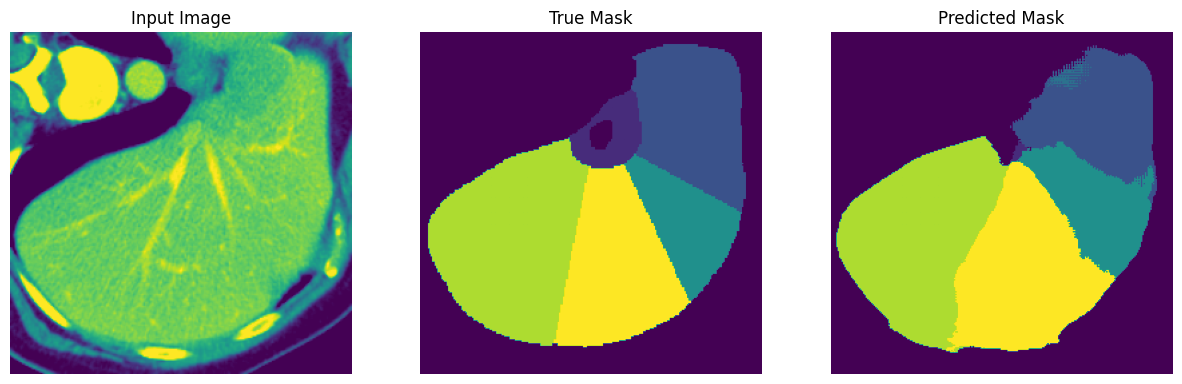

1/1 [==============================] - 0s 27ms/step


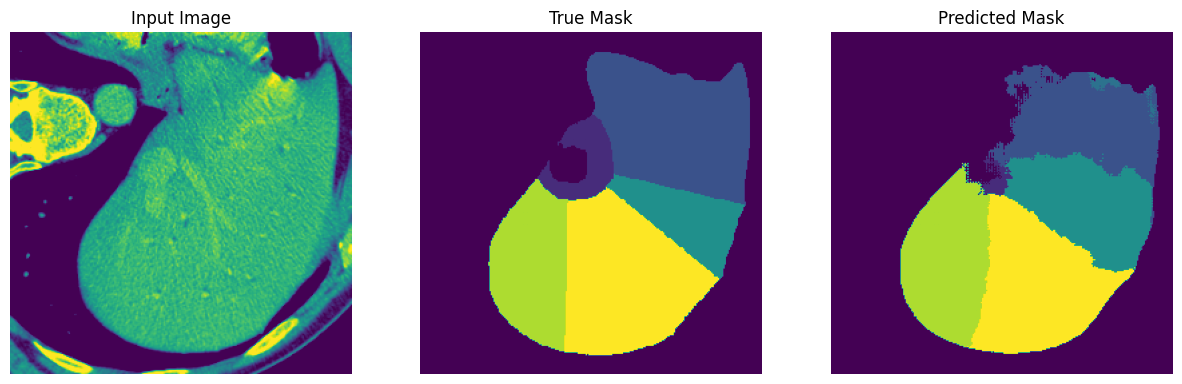

1/1 [==============================] - 0s 28ms/step


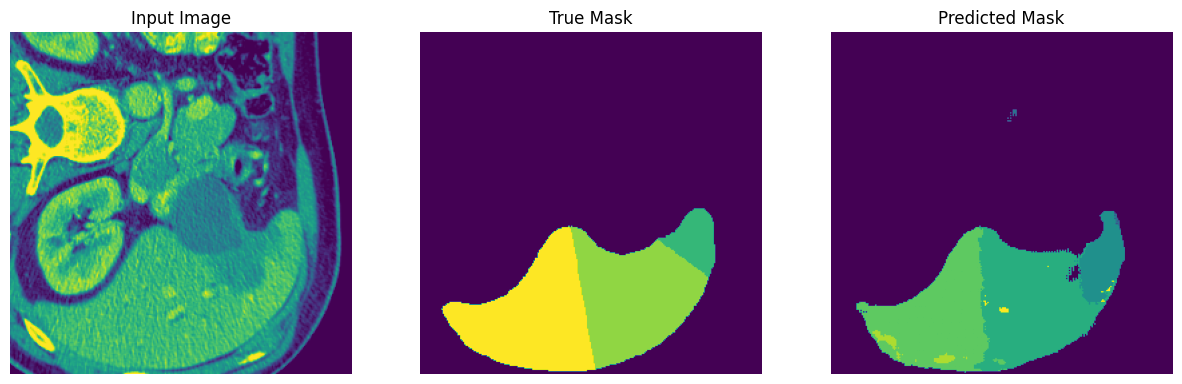

1/1 [==============================] - 0s 29ms/step


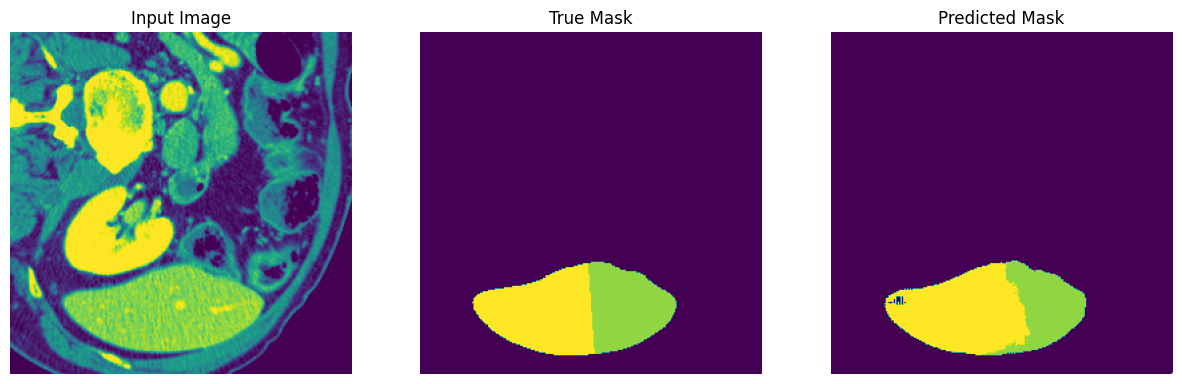

1/1 [==============================] - 0s 29ms/step


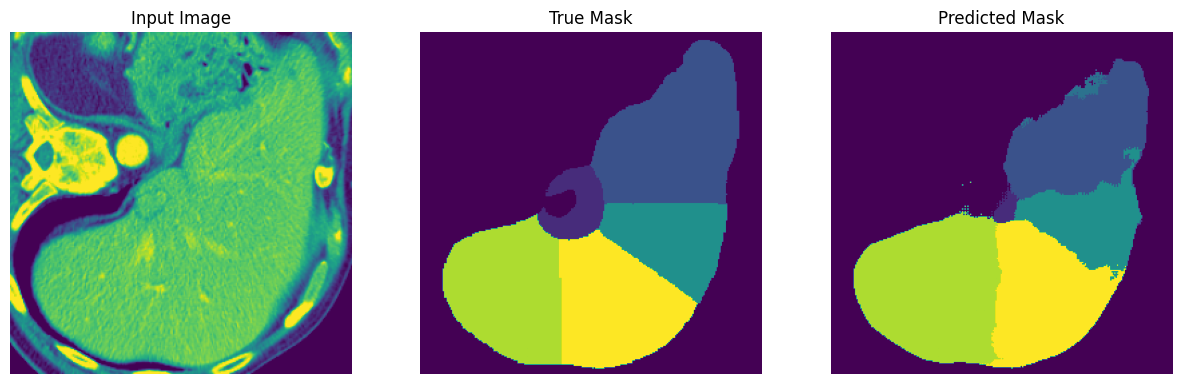

1/1 [==============================] - 0s 30ms/step


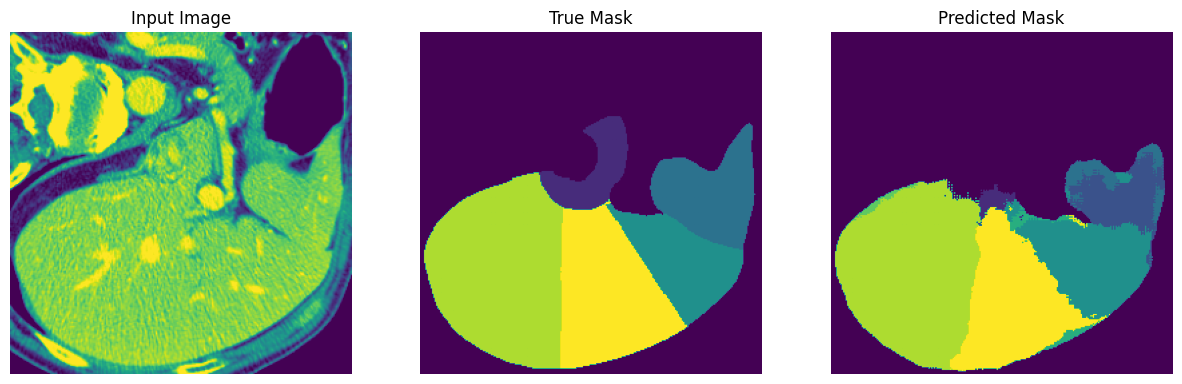

1/1 [==============================] - 0s 29ms/step


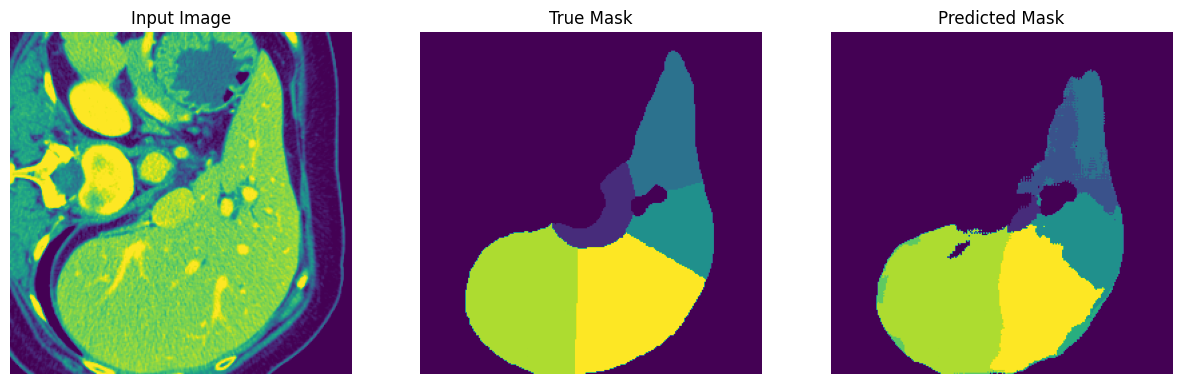

1/1 [==============================] - 0s 31ms/step


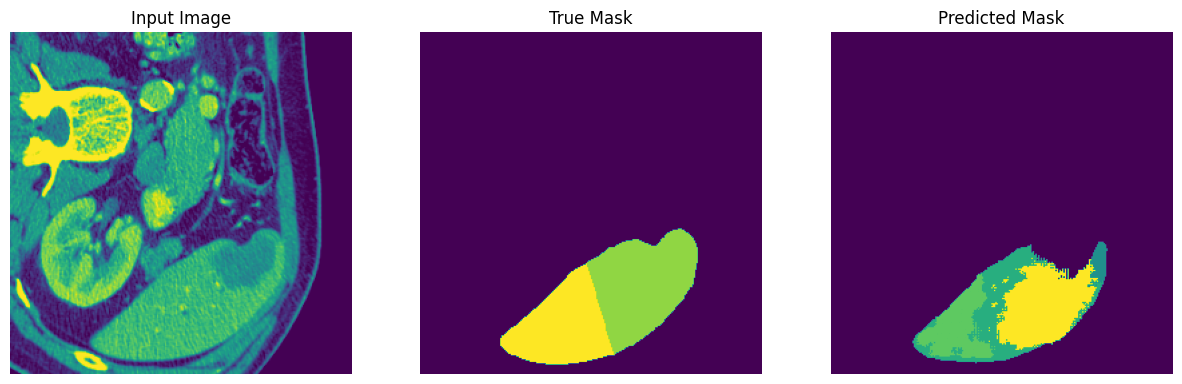

1/1 [==============================] - 0s 28ms/step


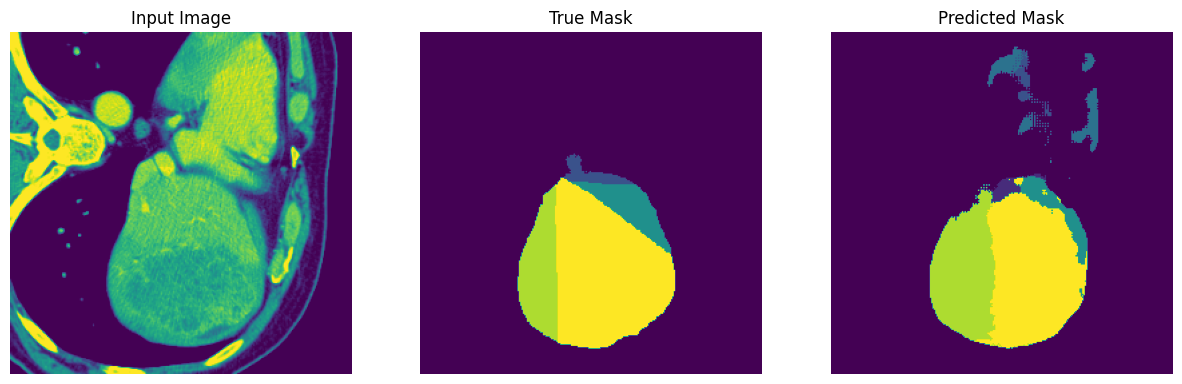

1/1 [==============================] - 0s 29ms/step


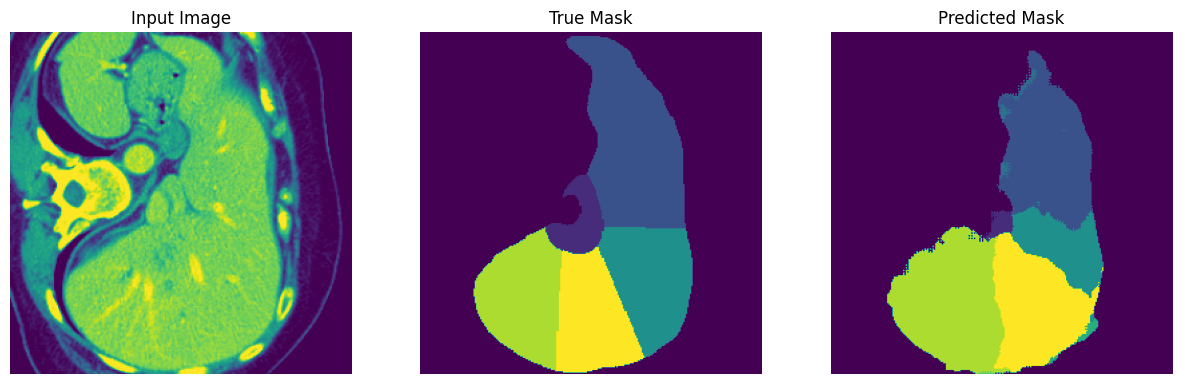

1/1 [==============================] - 0s 29ms/step


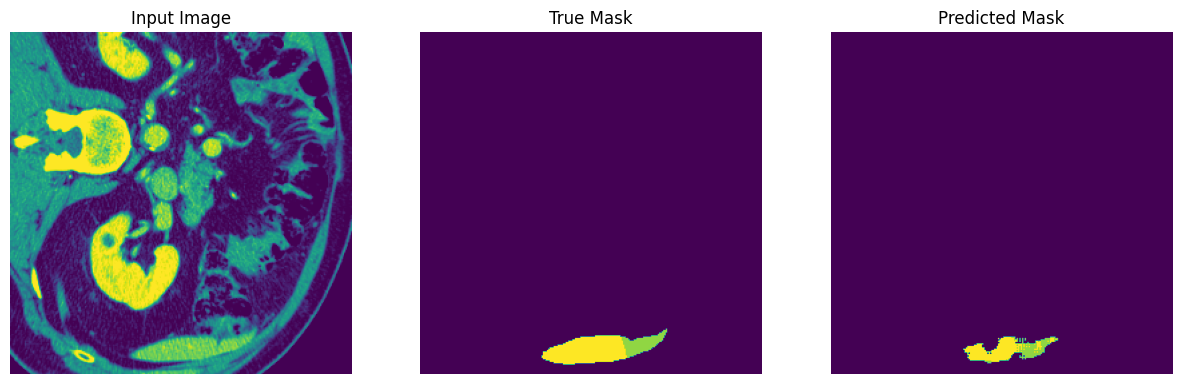

1/1 [==============================] - 0s 32ms/step


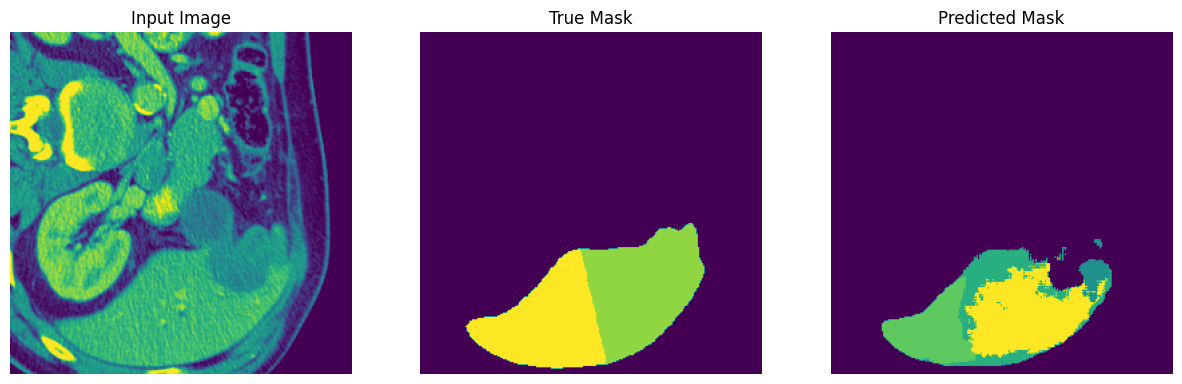

In [27]:
output_id = 0
for img, mask in valid_ds.shuffle(100).take(12):
    img_to_plot = img[0]
    mask_to_plot = tf.argmax(mask[0], axis=-1)
    
    predicted_batch = model.predict(img_to_plot[tf.newaxis, ...])
    predicted_mask = tf.argmax(predicted_batch[0], axis=-1) 
    
    display([img_to_plot[..., CONF['channels']//2], mask_to_plot, predicted_mask])
    np.savez(
        file=f'/kaggle/working/out_{output_id}',
        img=img_to_plot[..., CONF['channels']//2], 
        true=mask_to_plot,
        pred=predicted_mask
    )
    output_id += 1

In [28]:
def dice_loss(y_true, y_pred, smooth=1e-6):
    axes = (1, 2, 3) 
    intersection = K.sum(y_true * y_pred, axis=axes)
    sum_true = K.sum(y_true, axis=axes)
    sum_pred = K.sum(y_pred, axis=axes)
    dice_coeff = (2. * intersection + smooth) / (sum_true + sum_pred + smooth)
    return 1. - dice_coeff

def f1_score(y_true, y_pred, smooth=1e-6):
    axes = (1, 2, 3) 
    intersection = K.sum(y_true * y_pred, axis=axes)
    sum_true = K.sum(y_true, axis=axes)
    sum_pred = K.sum(y_pred, axis=axes)
    dice_coeff = (2. * intersection + smooth) / (sum_true + sum_pred + smooth)
    return dice_coeff

def iou_score(y_true, y_pred, smooth=1e-6):
    axes = (1, 2, 3) 
    intersection = K.sum(y_true * y_pred, axis=axes)
    sum_true = K.sum(y_true, axis=axes)
    sum_pred = K.sum(y_pred, axis=axes)
    union = sum_true + sum_pred - intersection
    iou = (intersection + smooth) / (union + smooth)
    return iou

def precision(y_true, y_pred, smooth=1e-6):
    axes = (1, 2, 3) 
    intersection = K.sum(y_true * y_pred, axis=axes)
    sum_pred = K.sum(y_pred, axis=axes)
    prec = (intersection + smooth) / (sum_pred + smooth)
    return prec

def recall(y_true, y_pred, smooth=1e-6):
    axes = (1, 2, 3) 
    intersection = K.sum(y_true * y_pred, axis=axes)
    sum_true = K.sum(y_true, axis=axes)
    rec = (intersection + smooth) / (sum_true + smooth)
    return rec

In [29]:
test_f1_metric = tf.keras.metrics.Mean(name='test_f1_score')
test_iou_metric = tf.keras.metrics.Mean(name='test_iou_score')
test_prec_metric = tf.keras.metrics.Mean(name='test_precision')
test_rec_metric = tf.keras.metrics.Mean(name='test_recall')
test_dice_loss_metric = tf.keras.metrics.Mean(name='test_dice_loss')

In [30]:
print("Running evaluation on test set...")
for images, masks in test_ds:
    y_pred = model(images, training=False)
    
    batch_f1 = f1_score(masks, y_pred)
    batch_iou = iou_score(masks, y_pred)
    batch_prec = precision(masks, y_pred)
    batch_rec = recall(masks, y_pred)
    batch_dice_loss = dice_loss(masks, y_pred)

    test_f1_metric.update_state(batch_f1)
    test_iou_metric.update_state(batch_iou)
    test_prec_metric.update_state(batch_prec)
    test_rec_metric.update_state(batch_rec)
    test_dice_loss_metric.update_state(batch_dice_loss)

print("Evaluation complete.")

print("\n--- Final Test Statistics (Averaged over all batches) ---")
print(f"Test Dice Loss:       {test_dice_loss_metric.result().numpy():.4f}")
print(f"Test F1-Score (Dice): {test_f1_metric.result().numpy():.4f}")
print(f"Test IoU (Jaccard):   {test_iou_metric.result().numpy():.4f}")
print(f"Test Precision:       {test_prec_metric.result().numpy():.4f}")
print(f"Test Recall:          {test_rec_metric.result().numpy():.4f}")

Running evaluation on test set...
Evaluation complete.

--- Final Test Statistics (Averaged over all batches) ---
Test Dice Loss:       0.1666
Test F1-Score (Dice): 0.8334
Test IoU (Jaccard):   0.7241
Test Precision:       0.8334
Test Recall:          0.8334


In [31]:
print("\n--- Evaluating on Test Dataset ---")
test_ds = get_dataset(TEST_SET, training=False, augment=False)

test_results = model.evaluate(test_ds)

print(f"\nTest Loss (CCE + Dice): {test_results[0]:.4f}")
print(f"Test F1-Score (Dice): {test_results[1]:.4f}")


--- Evaluating on Test Dataset ---
43/43 [==============================] - 4s 94ms/step - loss: 0.4913 - f1_score: 0.8334

Test Loss (CCE + Dice): 0.4913
Test F1-Score (Dice): 0.8334
